# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [15]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [16]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')



X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


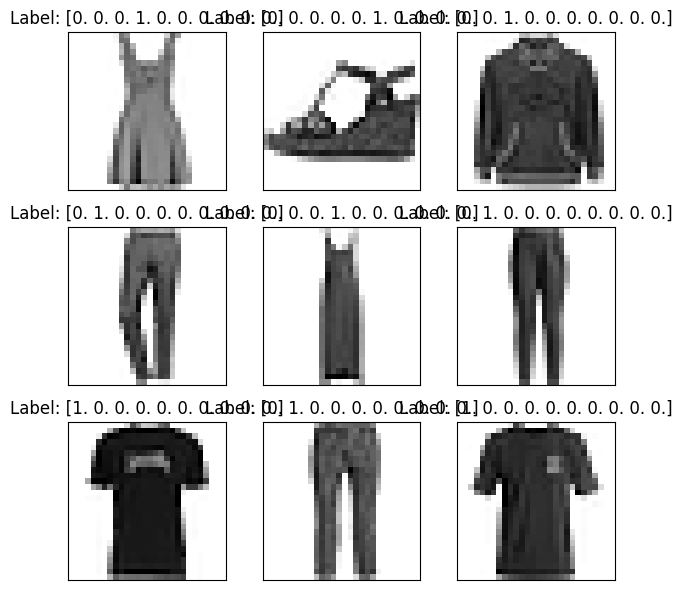

In [ ]:

import matplotlib.pyplot as plt
import numpy as np


#Selecting 9 random indices from x_train
random_indices = np.random.choice(len(X_train), 9, replace=False)

#Creating the grid
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    # random index to grab that specific random image
    ax.imshow(X_train[random_indices[i]], cmap='gray_r')
    
    # Use y_train label (the one hot encoding)
    ax.set_title(f"Label: {y_train[random_indices[i]]}")

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()




Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

Yes they actually look as expected. Just like the pixellated numbers in Lab-1, i see pixellated fashion items. I noticed that the label is still the one hot encoding instead of the shirt or clothes. 

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [37]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
import tensorflow as tf

# Create a simple linear regression model
model = Sequential()

# Input 
model.add(Input(shape=(28, 28)))  # Input tensor specifying the shape

#Flatten layer to convert 2D to 1D
model.add(Flatten())

# Output layer
model.add(Dense(10,))  # 10 neurons, no activation

model.summary()

# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=3, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1027 - loss: 9.4742 - val_accuracy: 0.1117 - val_loss: 9.5641
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1128 - loss: 9.7394 - val_accuracy: 0.1202 - val_loss: 9.1622
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1190 - loss: 9.3011 - val_accuracy: 0.1250 - val_loss: 9.2857
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1195 - loss: 9.3216
Loss:     9.32
Accuracy: 11.95%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model performance is only 11.95%. I thought it would be high like in 90s but there was no hidden layer so i suppose it lowers it.  

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [42]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

# Input Layer
model.add(Input(shape=(28, 28, 1)))

#convolution layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))

#Flatten layer
model.add(Flatten())

#Output layer
model.add(Dense(10, activation='softmax'))

#check architecture
model.summary()

# Train the model

model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Evaluate the model

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'\nTest Accuracy: {test_acc*100:.2f}%')

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │       216,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,650 (846.29 KB)

 Trainable params: 216,650 (846.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8495 - loss: 0.4330 - val_accuracy: 0.8810 - val_loss: 0.3448
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8920 - loss: 0.3006 - val_accuracy: 0.8884 - val_loss: 0.3085
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9062 - loss: 0.2598 - val_accuracy: 0.8898 - val_loss: 0.3068
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9165 - loss: 0.2330 - val_accuracy: 0.8942 - val_loss: 0.2994
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9249 - loss: 0.2089 - val_accuracy: 0.8987 - val_loss: 0.2970

Test Accuracy: 88.90%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN highly improved the model by around 75%. By adding a hidden layer for sure and the activation function.  

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout, Conv2D, Flatten, Dense, Input
from tensorflow.keras.models import Sequential

# Experimenting
filter_options = [32, 64, 128]
dropout_options = [0.0, 0.5] #0.0 no dropout (absence), 0.5 50% dropout (presence) this for
#section B. Test presence or absence of regularization

results = []

for dropout_rate in dropout_options:
    for num_filters in filter_options:
        print(f"\n--- Testing: {num_filters} filters, Dropout: {dropout_rate} ---")
        
        # Re-initialize the model for testing
        model = Sequential([
            Input(shape=(28, 28, 1)),
            Conv2D(num_filters, (3, 3), activation='relu'),
            Flatten(),
            # Regularization Technique
            Dropout(dropout_rate), 
            Dense(10, activation='softmax')
        ])
        
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        
        # Train (fewer epochs for speedup)
        model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)
        
        # Evaluate
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        results.append({
            'filters': num_filters,
            'dropout': dropout_rate,
            'accuracy': acc
        })
        print(f"Test Accuracy: {acc*100:.2f}%")


--- Testing: 32 filters, Dropout: 0.0 ---
Test Accuracy: 89.21%

--- Testing: 64 filters, Dropout: 0.0 ---
Test Accuracy: 89.19%

--- Testing: 128 filters, Dropout: 0.0 ---
Test Accuracy: 89.78%

--- Testing: 32 filters, Dropout: 0.5 ---
Test Accuracy: 88.94%

--- Testing: 64 filters, Dropout: 0.5 ---
Test Accuracy: 88.71%

--- Testing: 128 filters, Dropout: 0.5 ---
Test Accuracy: 88.78%


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

Yes, each combination change of filter number and presence or absence of regularization changes the accuracy. Adding (presence) of regularization lowers the accuracy of the numbers. whereas the hgiest filter increase the accuracy. The best combination is highest amount of filter number (128) and the absence of dropout. 

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Use the best hyperparameters found in your experiments
best_filters = 128 
best_dropout = 0.5

final_model = Sequential([
    Input(shape=(28, 28, 1)),
    
    # Convolutional Layer with best filter count
    Conv2D(best_filters, kernel_size=(3, 3), activation='relu'),
    
    # Reducing spatial dimensions to prevent overfitting
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    # Adding Regularization to help the model generalize to the test set
    Dropout(best_dropout),
    
    # Final classification layers
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

final_model.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,594 (10.57 MB)

 Trainable params: 2,771,594 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Or 'sparse_categorical_crossentropy' depending on your y_train format
    metrics=['accuracy']
)

# Training the final model
history = final_model.fit(
    X_train, 
    y_train, 
    epochs=15, 
    batch_size=64, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 80ms/step - accuracy: 0.8486 - loss: 0.4215 - val_accuracy: 0.8907 - val_loss: 0.3065
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.8948 - loss: 0.2908 - val_accuracy: 0.9018 - val_loss: 0.2686
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9058 - loss: 0.2539 - val_accuracy: 0.9047 - val_loss: 0.2619
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.9165 - loss: 0.2238 - val_accuracy: 0.9107 - val_loss: 0.2385
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9251 - loss: 0.1987 - val_accuracy: 0.9087 - val_loss: 0.2485
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9319 - loss: 0.1824 - val_accuracy: 0.9120 - val_loss: 0.2433
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9378 - loss: 0.1653 - val_accuracy: 0.9112 - val_loss: 0.2571
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9435 - loss: 0.1516 - 

In [48]:
# Evaluate on the test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)

print("--- FINAL MODEL PERFORMANCE ---")
print(f"Final Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

--- FINAL MODEL PERFORMANCE ---
Final Test Loss:     0.3096
Final Test Accuracy: 91.42%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final model has 91.42% accuracy and it is the highest compared to the baseline 11% and cnn at 88%. having the best combination input for the convolutional layer, also preventing overfitting and adding the activation functions. 

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.